In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import zipfile
import os
import pandas as pd

zip_file_path = '/content/archive.zip'

# List the contents of the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_contents = zip_ref.namelist()
    print("Contents of the zip file:")
    for item in zip_contents:
        print(item)

# Original code (commented out as it causes an error)
# import pandas as pd
# df = pd.read_csv('/content/archive.zip')  # works if zip contains a single csv

Contents of the zip file:
email/doc_000042.png
email/doc_000046.png
email/doc_000076.png
email/doc_000079.png
email/doc_000111.png
email/doc_000115.png
email/doc_000133.png
email/doc_000142.png
email/doc_000148.png
email/doc_000165.png
email/doc_000195.png
email/doc_000196.png
email/doc_000238.png
email/doc_000255.png
email/doc_000260.png
email/doc_000275.png
email/doc_000278.png
email/doc_000279.png
email/doc_000282.png
email/doc_000297.png
email/doc_000333.png
email/doc_000347.png
email/doc_000363.png
email/doc_000448.png
email/doc_000464.png
email/doc_000465.png
email/doc_000471.png
email/doc_000483.png
email/doc_000485.png
email/doc_000507.png
email/doc_000511.png
email/doc_000528.png
email/doc_000532.png
email/doc_000550.png
email/doc_000558.png
email/doc_000577.png
email/doc_000586.png
email/doc_000591.png
email/doc_000596.png
email/doc_000612.png
email/doc_000637.png
email/doc_000650.png
email/doc_000655.png
email/doc_000675.png
email/doc_000694.png
email/doc_000745.png
email/do

In [8]:
import zipfile

zip_path = "/content/archive.zip"
extract_path = "/content/archive"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [9]:
import os

os.listdir("/content/archive")

['resume', 'email', 'scientific_publication']

In [10]:
for root, dirs, files in os.walk("/content/archieve"):
    print(root, len(files))

In [11]:
import pandas as pd
import os

image_paths = []
labels = []

extract_base_path = "/content/archive"

# Walk through the extracted directories to find image files
for root, dirs, files in os.walk(extract_base_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(root, file)
            image_paths.append(image_path)
            # Extract label from the subdirectory name
            label = os.path.basename(root)
            labels.append(label)

# Create a DataFrame
df = pd.DataFrame({"image_path": image_paths, "text_label": labels})

df.tail()

,image_path,text_label
160,/content/archive/scientific_publication/doc_00...,scientific_publication
161,/content/archive/scientific_publication/doc_00...,scientific_publication
162,/content/archive/scientific_publication/doc_00...,scientific_publication
163,/content/archive/scientific_publication/doc_00...,scientific_publication
164,/content/archive/scientific_publication/doc_00...,scientific_publication


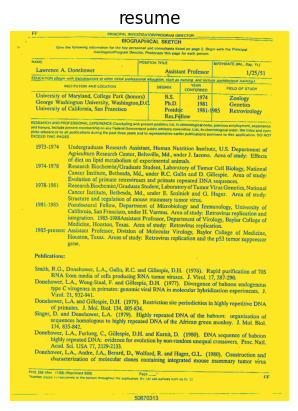

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os

# Ensure df is defined. If it's not, recreate it from the extracted images.
if 'df' not in locals() or df is None or df.empty:
    image_paths = []
    labels = []
    extract_base_path = "/content/archive"
    for root, dirs, files in os.walk(extract_base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(root, file)
                image_paths.append(image_path)
                label = os.path.basename(root)
                labels.append(label)
    df = pd.DataFrame({"image_path": image_paths, "text_label": labels})

img_path = df.iloc[0]['image_path']
label = df.iloc[0]['text_label']

img = Image.open(img_path)
plt.imshow(img)
plt.title(label)
plt.axis('off')
plt.show()

In [13]:
import cv2

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # grayscale often helps OCR
    img = cv2.resize(img, (128, 32))  # resize to consistent shape (adjust to your model's needs)
    img = img / 255.0  # normalize pixel values
    return img

In [14]:
df['processed_image'] = df['image_path'].apply(lambda x: preprocess_image(x))

In [15]:
all_chars = set(''.join(df['text_label'].astype(str)))
print(sorted(all_chars))
print(f"Vocab size: {len(all_chars)}")

['_', 'a', 'b', 'c', 'e', 'f', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u']
Vocab size: 16


In [16]:
# Sorted vocab for consistency
vocab = sorted(set(''.join(df['text_label'].astype(str))))

# Create mappings
# Assign character indices from 0 to len(vocab)-1
char_to_idx = {char: idx for idx, char in enumerate(vocab)}
# Assign the blank token the highest index, which is len(vocab)
char_to_idx['<blank>'] = len(vocab) # This will be 16 in our case (16 characters + 1 blank = 17 total classes, blank is at index 16)

idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(char_to_idx)

{'_': 0, 'a': 1, 'b': 2, 'c': 3, 'e': 4, 'f': 5, 'i': 6, 'l': 7, 'm': 8, 'n': 9, 'o': 10, 'p': 11, 'r': 12, 's': 13, 't': 14, 'u': 15, '<blank>': 16}


In [17]:
def encode_label(text):
    return [char_to_idx[c] for c in text]

df['encoded_label'] = df['text_label'].apply(encode_label)

In [18]:
print(df[['text_label', 'encoded_label']].head())

  text_label          encoded_label
0     resume  [12, 4, 13, 15, 8, 4]
1     resume  [12, 4, 13, 15, 8, 4]
2     resume  [12, 4, 13, 15, 8, 4]
3     resume  [12, 4, 13, 15, 8, 4]
4     resume  [12, 4, 13, 15, 8, 4]


In [19]:
max_len = df['encoded_label'].apply(len).max()
print("Max label length:", max_len)

def pad_label(seq, max_len):
  if not seq:
    return [char_to_idx['<blank>']] * max_len # Handle empty sequence case if needed
  # Pad with the blank token (0) at the end
  return seq + [char_to_idx['<blank>']] * (max_len - len(seq))

df['padded_label'] = df['encoded_label'].apply(lambda x: pad_label(x, max_len))

Max label length: 22


In [20]:
import pandas as pd

# Assuming char_to_idx and max_len are correctly defined in previous cells

# Redefine encode_label locally for demonstration to ensure we get unpadded values
def _temp_encode_label(text):
    return [char_to_idx[c] for c in text]

# Redefine pad_label locally for demonstration to append blank tokens
def _temp_pad_label(seq, max_len):
  if not seq:
    return [char_to_idx['<blank>']] * max_len # Handle empty sequence case if needed
  # Pad with the blank token (0) at the end
  return seq + [char_to_idx['<blank>']] * (max_len - len(seq))

# Create temporary series with the correct (unpadded) encoded labels
correct_encoded_label_series = df['text_label'].apply(_temp_encode_label)

# Create temporary series with the correctly padded labels
correct_padded_label_series = correct_encoded_label_series.apply(lambda x: _temp_pad_label(x, max_len))

# Create a temporary DataFrame for printing the head with correct columns
temp_df_for_print = pd.DataFrame({
    'text_label': df['text_label'],
    'encoded_label (unpadded)': correct_encoded_label_series,
    'padded_label': correct_padded_label_series
})

print(temp_df_for_print.head())

  text_label encoded_label (unpadded)  \
0     resume    [12, 4, 13, 15, 8, 4]   
1     resume    [12, 4, 13, 15, 8, 4]   
2     resume    [12, 4, 13, 15, 8, 4]   
3     resume    [12, 4, 13, 15, 8, 4]   
4     resume    [12, 4, 13, 15, 8, 4]   

                                        padded_label  
0  [12, 4, 13, 15, 8, 4, 16, 16, 16, 16, 16, 16, ...  
1  [12, 4, 13, 15, 8, 4, 16, 16, 16, 16, 16, 16, ...  
2  [12, 4, 13, 15, 8, 4, 16, 16, 16, 16, 16, 16, ...  
3  [12, 4, 13, 15, 8, 4, 16, 16, 16, 16, 16, 16, ...  
4  [12, 4, 13, 15, 8, 4, 16, 16, 16, 16, 16, 16, ...  


In [21]:
print(char_to_idx)  # check mapping is still correct (e/m/a/i/l should map to different numbers)
print(len(df['encoded_label'].iloc[0]))  # check actual length — should be 5 for "email"

{'_': 0, 'a': 1, 'b': 2, 'c': 3, 'e': 4, 'f': 5, 'i': 6, 'l': 7, 'm': 8, 'n': 9, 'o': 10, 'p': 11, 'r': 12, 's': 13, 't': 14, 'u': 15, '<blank>': 16}
6


In [22]:
print(repr(df['text_label'].iloc[0]))

'resume'


In [23]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.stack(df['processed_image'].values)
y = np.stack(df['padded_label'].values)

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2,random_state = 42)
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

X shape: (165, 32, 128)
y shape: (165, 22)
Train: (132, 32, 128) (132, 22)
Val: (33, 32, 128) (33, 22)


In [30]:
def ctc_loss(y_true, y_pred):
    batch_len = tf.shape(y_true)[0]
    input_length = tf.ones((batch_len, 1)) * tf.cast(tf.shape(y_pred)[1], "float32")

    # label_length should count non-blank characters. With the new mapping, char_to_idx['<blank>'] is len(vocab).
    label_length = tf.reduce_sum(tf.cast(y_true != char_to_idx['<blank>'], "float32"), axis=1, keepdims=True)

    # Remove the blank_label argument, as it's assumed to be vocab_size (highest index) by default.
    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

model.compile(optimizer='adam', loss=ctc_loss)

In [41]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=30
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - loss: 8.7313 - val_loss: 8.2127
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step - loss: 7.9307 - val_loss: 13.9270
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - loss: 10.5930 - val_loss: 11.5035
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - loss: 11.6098 - val_loss: 13.0250
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 10.3824 - val_loss: 9.6697
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - loss: 8.8715 - val_loss: 8.4323
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - loss: 7.6960 - val_loss: 8.8985
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step - loss: 7.7970 - val_loss: 9.4195
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - loss: 9.9939 - val_loss: 9.9716
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - loss: 8.8152 - val_loss: 8.9876
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - loss: 6.7501 - val_loss: 8.3878
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - loss: 6.0275 - 

In [33]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# 1. Vocab (blank token now LAST, not first)
vocab = sorted(set(''.join(df['text_label'].astype(str))))
char_to_idx = {char: idx for idx, char in enumerate(vocab)}  # 0-indexed, no +1
blank_idx = len(vocab)  # blank = last index
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print("char_to_idx:", char_to_idx)
print("blank_idx:", blank_idx)

# 2. Encode labels
def encode_label(text):
    return [char_to_idx[c] for c in text]

df['encoded_label'] = df['text_label'].apply(encode_label)

# 3. Pad labels (pad with blank_idx, not 0)
max_len = df['encoded_label'].apply(len).max()

def pad_label(seq, max_len):
    return seq + [blank_idx] * (max_len - len(seq))

df['padded_label'] = df['encoded_label'].apply(lambda x: pad_label(x, max_len))

# 4. Arrays + split
X = np.stack(df['processed_image'].values)
y = np.stack(df['padded_label'].values)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

# 5. rebuild model (vocab_size stays 16, output layer = vocab_size + 1 for blank)
def build_crnn(input_shape, vocab_size):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    new_shape = (x.shape[2], x.shape[1] * x.shape[3])
    x = layers.Reshape(target_shape=new_shape)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    outputs = layers.Dense(vocab_size + 1, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_crnn(input_shape=(32, 128, 1), vocab_size=len(vocab))

# 6. CTC loss (now aligned with blank_idx = last class)
def ctc_loss(y_true, y_pred):
    batch_len = tf.shape(y_true)[0]
    input_length = tf.ones((batch_len, 1)) * tf.cast(tf.shape(y_pred)[1], "float32")
    label_length = tf.reduce_sum(tf.cast(y_true != blank_idx, "float32"), axis=1, keepdims=True)
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

model.compile(optimizer='adam', loss=ctc_loss)
model.summary()

char_to_idx: {'_': 0, 'a': 1, 'b': 2, 'c': 3, 'e': 4, 'f': 5, 'i': 6, 'l': 7, 'm': 8, 'n': 9, 'o': 10, 'p': 11, 'r': 12, 's': 13, 't': 14, 'u': 15}
blank_idx: 16
Train: (132, 32, 128, 1) (132, 22)
Val: (33, 32, 128, 1) (33, 22)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 32, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 32, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 32, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32, 17)         │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841,745 (3.21 MB)

 Trainable params: 841,745 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history3 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step - loss: 13.0235 - val_loss: 12.8932
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - loss: 13.7454 - val_loss: 11.3214
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - loss: 12.1858 - val_loss: 10.8376
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - loss: 11.9917 - val_loss: 10.3631
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - loss: 11.3522 - val_loss: 10.9586
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - loss: 11.0603 - val_loss: 10.6393
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - loss: 11.0087 - val_loss: 10.0327
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 11.4599 - val_loss: 10.6116
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - loss: 11.5684 - val_loss: 11.0009
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - loss: 10.7467 - val_loss: 9.8664
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - loss: 10.1069 - val_loss: 9.8016
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - l

In [36]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

In [38]:
import numpy as np

def decode_prediction(pred, idx_to_char, blank_idx):
    pred_indices = np.argmax(pred, axis=-1)  # get most likely class per timestep

    decoded = []
    prev = None
    for idx in pred_indices:
        if idx != blank_idx and idx != prev:  # remove blanks + collapse repeats (CTC decoding rule)
            decoded.append(idx_to_char[idx])
        prev = idx
    return ''.join(decoded)

# test on a few validation samples
predictions = model.predict(X_val[:5])

for i in range(5):
    pred_text = decode_prediction(predictions[i], idx_to_char, blank_idx)
    true_text = ''.join([idx_to_char[idx] for idx in y_val[i] if idx != blank_idx])
    print(f"True: {true_text}  |  Predicted: {pred_text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
True: scientific_publication  |  Predicted: scetumion
True: scientific_publication  |  Predicted: scientcpublication
True: scientific_publication  |  Predicted: scientublicaton
True: email  |  Predicted: email
True: email  |  Predicted: email


In [42]:
model = build_crnn(input_shape=(32, 128, 1), vocab_size=len(vocab))
model.compile(optimizer='adam', loss=ctc_loss)
model.summary()  # optional, just to confirm it rebuilt correctly

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 32, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 32, 256)        │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 32, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32, 17)         │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841,745 (3.21 MB)

 Trainable params: 841,745 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_crnn(input_shape, vocab_size):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    new_shape = (x.shape[2], x.shape[1] * x.shape[3])
    x = layers.Reshape(target_shape=new_shape)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    outputs = layers.Dense(vocab_size + 1, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_crnn(input_shape=(32, 128, 1), vocab_size=len(vocab))

def ctc_loss(y_true, y_pred):
    batch_len = tf.shape(y_true)[0]
    input_length = tf.ones((batch_len, 1)) * tf.cast(tf.shape(y_pred)[1], "float32")
    label_length = tf.reduce_sum(tf.cast(y_true != blank_idx, "float32"), axis=1, keepdims=True)
    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

model.compile(optimizer='adam', loss=ctc_loss)

In [46]:
model.save('/content/ocr_model.keras')

In [57]:
predictions = model.predict(X_val[:5])

for i in range(5):
    pred_text = decode_prediction(predictions[i], idx_to_char, blank_idx)
    true_text = ''.join([idx_to_char[idx] for idx in y_val[i] if idx != blank_idx])
    print(f"True: {true_text}  |  Predicted: {pred_text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
True: scientific_publication  |  Predicted: lb
True: scientific_publication  |  Predicted: lb
True: scientific_publication  |  Predicted: lb
True: email  |  Predicted: lb
True: email  |  Predicted: lb


In [66]:
import random

def augment_image(img):
    shift_x = random.randint(-3, 3)
    shift_y = random.randint(-2, 2)
    img_shifted = np.roll(img, shift_x, axis=1)
    img_shifted = np.roll(img_shifted, shift_y, axis=0)
    noise = np.random.normal(0, 0.02, img.shape)
    return np.clip(img_shifted + noise, 0, 1)

# Rebuild from X_train (128-width), NOT X_train_wide
X_train_aug = np.array([augment_image(img.squeeze()) for img in X_train])
X_train_aug = np.expand_dims(X_train_aug, axis=-1)

X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
y_train_combined = np.concatenate([y_train, y_train], axis=0)

print("X_train_combined shape:", X_train_combined.shape)  # should be (264, 32, 128, 1)

X_train_combined shape: (264, 32, 128, 1)


In [68]:
predictions = model.predict(X_val)

correct = 0
total = len(X_val)

for i in range(total):
    pred_text = decode_prediction(predictions[i], idx_to_char, blank_idx)
    true_text = ''.join([idx_to_char[idx] for idx in y_val[i] if idx != blank_idx])
    match = "✅" if pred_text == true_text else "❌"
    print(f"{match} True: {true_text}  |  Predicted: {pred_text}")
    if pred_text == true_text:
        correct += 1

accuracy = correct / total * 100
print(f"\nExact match accuracy: {correct}/{total} = {accuracy:.1f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
✅ True: scientific_publication  |  Predicted: scientific_publication
✅ True: scientific_publication  |  Predicted: scientific_publication
✅ True: scientific_publication  |  Predicted: scientific_publication
✅ True: email  |  Predicted: email
✅ True: email  |  Predicted: email
✅ True: resume  |  Predicted: resume
✅ True: scientific_publication  |  Predicted: scientific_publication
✅ True: resume  |  Predicted: resume
❌ True: email  |  Predicted: scetumail
✅ True: scientific_publication  |  Predicted: scientific_publication
❌ True: resume  |  Predicted: scientific_publication
✅ True: email  |  Predicted: email
✅ True: resume  |  Predicted: resume
✅ True: email  |  Predicted: email
✅ True: resume  |  Predicted: resume
❌ True: resume  |  Predicted: rcesume
✅ True: scientific_publication  |  Predicted: scientific_publication
✅ True: email  |  Predicted: email
✅ True: scientific_publication  |  Predicted: scientific_publication
✅ True: resume  |  Predict

In [54]:
print(model)

<Functional name=functional_5, built=True>


In [62]:
import random
import numpy as np
import tensorflow as tf

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [63]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    '/content/best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [67]:
best_accuracy = 0
for seed in [42, 7, 123]:
    tf.random.set_seed(seed)
    model = build_crnn(input_shape=(32, 128, 1), vocab_size=len(vocab))
    model.compile(optimizer='adam', loss=ctc_loss)

    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)  # redefine fresh each loop

    hist = model.fit(X_train_combined, y_train_combined, validation_data=(X_val, y_val),
              batch_size=16, epochs=50, callbacks=[early_stop], verbose=0)

    print(f"Seed {seed} — final loss: {hist.history['loss'][-1]:.2f}, final val_loss: {hist.history['val_loss'][-1]:.2f}")

    predictions = model.predict(X_val, verbose=0)
    correct = sum(1 for i in range(len(X_val)) if decode_prediction(predictions[i], idx_to_char, blank_idx) == ''.join([idx_to_char[idx] for idx in y_val[i] if idx != blank_idx]))
    acc = correct/len(X_val)*100
    print(f"Seed {seed}: {acc:.1f}%")
    if acc > best_accuracy:
        best_accuracy = acc
        model.save('/content/best_ocr_model.keras')

Seed 42 — final loss: 9.49, final val_loss: 10.53
Seed 42: 33.3%
Seed 7 — final loss: 5.06, final val_loss: 9.68
Seed 7: 75.8%
Seed 123 — final loss: 0.49, final val_loss: 6.57
Seed 123: 81.8%
